# Part 6 — Wilson-Cowan E/I Circuit Model

Fits a two-population Wilson-Cowan firing-rate model to RSU (E population)
and FSU (I population) temporal dynamics. The key parameter is
r_EI = w_EE / w_IE. The model is fit to three different targets in turn —
cross-mouse consistency curves, total firing rate, and image-selective
firing-rate amplitude — and cross-validated over sessions.

**Depends on:** `part5_outputs.npz`, `responses.h5`, `units_meta.parquet`.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path(".").resolve()))
from utils import (
    setup_archive,
    window_response,
    compute_similarity_matrices,
    per_image_consistency,
    cluster_bootstrap_ci,
    apply_plot_style,
    ts_ratio,
    print_figure_data,
)

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.integrate import odeint
from scipy.optimize import minimize
from scipy.stats import gamma as gamma_dist
from sklearn.model_selection import KFold

SEED = 42
rng  = np.random.default_rng(SEED)

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.labelsize': 12, 'axes.titlesize': 12,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'legend.fontsize': 9.5, 'figure.dpi': 150,
})
sns.set_style('ticks')

colors   = apply_plot_style()
COL_DATA = colors["COL_DATA"]            # train split (6C), same metric as COL_TEST
COL_TEST = colors["COL_TEST"]            # test split (6C), light tint of COL_DATA
COL_RSU  = colors["COL_RSU"]             # RSU / E population — same category as Part 5
COL_FSU  = colors["COL_FSU"]             # FSU / I population — same category as Part 5
COL_FIT  = colors["COL_FIT"]             # fitted model curves / annotations
COL_REF  = colors["COL_REF"]
COL_REI  = colors["COL_REI"]             # r_EI parameter (own dedicated quantity)
COL_INFORMED_START = colors["COL_INFORMED_START"]   # informed-start robustness check
COL_TARGET_CONSISTENCY = colors["COL_TARGET_CONSISTENCY"]  # fit target: consistency
COL_TARGET_TOTAL_RATE  = colors["COL_TARGET_TOTAL_RATE"]   # fit target: total rate
COL_TARGET_SELECTIVE   = colors["COL_TARGET_SELECTIVE"]    # fit target: selective amplitude

In [2]:
# Load archive, extract if needed, resolve output paths.
manifest, bin_edges, ARCHIVE_DIR, FIGURES_DIR, OUTPUTS_DIR = setup_archive(
    zip_path    = '../preprocessed_data.zip',
    archive_dir = '../preprocessed_data',
    figures_dir = '../figures',
    outputs_dir = '.',
)

p5 = np.load(OUTPUTS_DIR / 'part5_outputs.npz')
ts_rsu       = p5['ts_rsu'].astype(float)
mc_rsu       = p5['mc_rsu'].astype(float)
ts_fsu       = p5['ts_fsu'].astype(float)
mc_fsu       = p5['mc_fsu'].astype(float)
ts_ratio_rsu = float(p5['ts_ratio_rsu'])
ts_ratio_fsu = float(p5['ts_ratio_fsu'])

print(f'RSU curve: {len(ts_rsu)} windows, peak = {mc_rsu.max():.3f}, T/S = {ts_ratio_rsu:.2f}×')
print(f'FSU curve: {len(ts_fsu)} windows, peak = {mc_fsu.max():.3f}, T/S = {ts_ratio_fsu:.2f}×')

Archive already extracted: C:\Users\janak\GitHub\cross-mouse-v1-rsa\preprocessed_data
Manifest: 32 VISp sessions | 118 images | 479 bins × 1 ms
RSU curve: 43 windows, peak = 0.217, T/S = 1.71×
FSU curve: 43 windows, peak = 0.245, T/S = 2.29×


## 6.1 — Wilson-Cowan E/I model definition

The model is reparameterized with r_EI = w_EE / w_IE as an explicit free
parameter (bounded [0.01, 2.0]), separating the identifiable quantity of
interest from the overall inhibitory scale (w_IE), which is a nuisance
parameter. r_EI < 1 = inhibition-dominated; r_EI > 1 = recurrence-dominated.

Time constants are fixed at biologically motivated values (τ_E = 20 ms,
τ_I = 10 ms). The thalamic drive D(t) is a gamma-shaped function with
onset at 40 ms, shared by both populations.

In [3]:
# ── Thalamic drive (gamma-shaped, onset 40 ms) ────────────────────────────────
_ONSET  = 40.0
_K      = 5.0
_THETA  = 14.0
_NORM   = gamma_dist.pdf((_K - 1) * _THETA, a=_K, scale=_THETA) + 1e-8

def thalamic_drive(t_ms, amp):
    t_s = t_ms - _ONSET
    if t_s <= 0:
        return 0.0
    return amp * gamma_dist.pdf(t_s, a=_K, scale=_THETA) / _NORM

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -20, 20)))


# ── Reparameterized Wilson-Cowan ODE ─────────────────────────────────────────
#  dE/dt = (−E + σ(r_EI·w_IE·E − w_IE·I + D(t)))   / τ_E
#  dI/dt = (−I + σ(w_EI·E     − w_II·I + 0.7·D(t))) / τ_I
TAU_E = 20.0   # ms — fixed
TAU_I = 10.0   # ms — fixed

def ei_ode(y, t_ms, r_EI, w_IE, w_EI, w_II, I_amp):
    E, I  = y
    D     = thalamic_drive(t_ms, I_amp)
    dE = (-E + sigmoid(r_EI * w_IE * E - w_IE * I + D))       / TAU_E
    dI = (-I + sigmoid(w_EI         * E - w_II * I + 0.7 * D)) / TAU_I
    return [dE, dI]

def simulate(params, t_eval_ms):
    r_EI, w_IE, w_EI, w_II, I_amp = params
    sol = odeint(ei_ode, [0.01, 0.01], t_eval_ms,
                 args=(r_EI, w_IE, w_EI, w_II, I_amp),
                 rtol=1e-6, atol=1e-8)
    return sol[:, 0], sol[:, 1]   # E, I trajectories

print('Model defined.  τ_E =', TAU_E, 'ms,  τ_I =', TAU_I, 'ms')

Model defined.  τ_E = 20.0 ms,  τ_I = 10.0 ms


## 6.2 — Fit to consistency curves

The model is fit by minimising the sum of mean-squared errors between
amplitude-normalised model outputs and the normalised RSU/FSU consistency
curves simultaneously (L-BFGS-B). Ten initialisations (one informed, nine
random) are used to check whether the optimum is unique.

In [4]:
BOUNDS = [
    (0.01, 2.0),    # r_EI  — KEY PARAMETER
    (0.1,  20.0),   # w_IE
    (0.1,  15.0),   # w_EI
    (0.0,   8.0),   # w_II
    (0.5,  20.0),   # I_amp
]

# Restrict fit to the 0–250 ms post-stimulus clean window
def prep_curves(ts_r, mc_r, ts_f, mc_f):
    clean_r = (ts_r >= 0) & (ts_r <= 250)
    clean_f = (ts_f >= 0) & (ts_f <= 250)
    t_r, c_r = ts_r[clean_r], mc_r[clean_r]
    t_f, c_f = ts_f[clean_f], mc_f[clean_f]
    c_r_n = (c_r - c_r.min()) / (c_r.max() - c_r.min() + 1e-8)
    c_f_n = (c_f - c_f.min()) / (c_f.max() - c_f.min() + 1e-8)
    return t_r, c_r, c_r_n, t_f, c_f, c_f_n

t_r, c_r, c_r_n, t_f, c_f, c_f_n = prep_curves(ts_rsu, mc_rsu, ts_fsu, mc_fsu)

def r2_score(y, yhat):
    return 1 - np.sum((y - yhat)**2) / np.sum((y - y.mean())**2)

def loss(params):
    try:
        E, I = simulate(params, t_r)
        E_n  = (E - E.min()) / (E.max() - E.min() + 1e-8)
        I_n  = (I - I.min()) / (I.max() - I.min() + 1e-8)
        return np.mean((E_n - c_r_n)**2) + np.mean((I_n - c_f_n)**2)
    except Exception:
        return 1e6

# Informed initial guess + 9 random starts
x0_informed = np.array([0.65, 10.0, 4.0, 4.0, 10.0])
starts = [x0_informed] + [
    rng.uniform([b[0] for b in BOUNDS], [b[1] for b in BOUNDS])
    for _ in range(9)
]

best_result = None
stab_r_EI   = []
for i, x0 in enumerate(starts):
    try:
        res = minimize(loss, x0, method='L-BFGS-B', bounds=BOUNDS,
                       options={'maxiter': 3000, 'ftol': 1e-13, 'gtol': 1e-9})
        stab_r_EI.append(res.x[0])
        if best_result is None or res.fun < best_result.fun:
            best_result = res
    except Exception:
        pass

stab_r_EI = np.array(stab_r_EI)
r_EI_fit, w_IE_fit, w_EI_fit, w_II_fit, I_amp_fit = best_result.x

print(f'Optimisation success: {best_result.success}')
print(f'Loss: {best_result.fun:.6f}')
print(f'\nFitted parameters:')
print(f'  r_EI = w_EE/w_IE : {r_EI_fit:.4f}  ← KEY PARAMETER')
print(f'  w_IE             : {w_IE_fit:.3f}')
print(f'  w_EI             : {w_EI_fit:.3f}')
print(f'  w_II             : {w_II_fit:.3f}  '
      f'{"(at upper bound)" if abs(w_II_fit - BOUNDS[3][1]) < 0.01 else ""}')
print(f'  I_amp            : {I_amp_fit:.3f}')
print(f'\nr_EI < 1: {r_EI_fit < 1}')
print(f'Stability: mean r_EI = {stab_r_EI.mean():.3f} ± {stab_r_EI.std():.3f}  '
      f'(all < 1: {(stab_r_EI < 1).all()})')

# Compute R² on the amplitude-rescaled fit
E_fit, I_fit = simulate(best_result.x, t_r)
E_sc = E_fit * (c_r.max() - c_r.min()) + c_r.min()
I_sc = I_fit * (c_f.max() - c_f.min()) + c_f.min()
r2_E = r2_score(c_r, E_sc)
r2_I = r2_score(c_f, I_sc)
print(f'\nR²(RSU) = {r2_E:.3f},  R²(FSU) = {r2_I:.3f}')

Optimisation success: True
Loss: 0.020883

Fitted parameters:
  r_EI = w_EE/w_IE : 0.6305  ← KEY PARAMETER
  w_IE             : 10.837
  w_EI             : 4.168
  w_II             : 8.000  (at upper bound)
  I_amp            : 9.683

r_EI < 1: True
Stability: mean r_EI = 0.630 ± 0.000  (all < 1: True)

R²(RSU) = 0.894,  R²(FSU) = 0.908


## 6.3 — Firing-rate PSTHs

Computes population firing-rate curves for the RSU and FSU pools directly
from the raw spike-count tensors (`responses.h5`), using the same unit
classification, sessions, and sliding-window grid as the consistency
curves in Part 5. Two variants are computed: total firing rate (summed
across images and units) and image-selective amplitude (per-unit standard
deviation of firing rate across images, averaged over the pool) — the
latter matches the per-unit z-scoring applied in `window_response()`
before consistency is computed.

In [5]:
import h5py

WF_THRESHOLD_MS  = 0.4   # matches Part 5
MIN_UNITS_SUBPOP = 8     # matches Part 5

units_meta = pd.read_parquet(ARCHIVE_DIR / 'units_meta.parquet')
units_visp = units_meta[units_meta['area'] == 'VISp'].copy()
visp_wf    = units_visp.dropna(subset=['waveform_duration']).copy()

SESSION_IDS = manifest['selected_session_ids_visp']

print('Loading VISp tensors for firing-rate PSTHs...')
rate_tensors = {}
with h5py.File(ARCHIVE_DIR / 'responses.h5', 'r') as f:
    for sid in SESSION_IDS:
        grp = f[f'natural_scenes/VISp/{sid}']
        rate_tensors[sid] = {
            'tensor':   grp['tensor'][:],
            'unit_ids': grp['unit_ids'][:],
        }
print('Done.')

rate_rsu_idx = {}
rate_fsu_idx = {}
for sid in SESSION_IDS:
    uid_arr  = rate_tensors[sid]['unit_ids']
    sess_wf  = visp_wf[visp_wf['ecephys_session_id'] == sid]
    rsu_keep = set(sess_wf.loc[sess_wf['waveform_duration'] >= WF_THRESHOLD_MS, 'unit_id'])
    fsu_keep = set(sess_wf.loc[sess_wf['waveform_duration'] <  WF_THRESHOLD_MS, 'unit_id'])
    rsu_idx  = [i for i, uid in enumerate(uid_arr) if uid in rsu_keep]
    fsu_idx  = [i for i, uid in enumerate(uid_arr) if uid in fsu_keep]
    if len(rsu_idx) >= MIN_UNITS_SUBPOP:
        rate_rsu_idx[sid] = rsu_idx
    if len(fsu_idx) >= MIN_UNITS_SUBPOP:
        rate_fsu_idx[sid] = fsu_idx

print(f'RSU sessions: {len(rate_rsu_idx)}  |  FSU sessions: {len(rate_fsu_idx)}')


def session_rate_curve(tensor, unit_idx, window_centers_ms, width_ms, bin_edges):
    """Mean per-unit, per-image firing rate (Hz) in each sliding window."""
    n_images = tensor.shape[0]
    n_units  = len(unit_idx)
    rates = np.zeros(len(window_centers_ms))
    for k, t_ms in enumerate(window_centers_ms):
        lo = np.searchsorted(bin_edges, t_ms - width_ms / 2)
        hi = np.searchsorted(bin_edges, t_ms + width_ms / 2)
        window_s = (hi - lo) * (bin_edges[1] - bin_edges[0]) / 1000.0
        rates[k] = tensor[:, unit_idx, lo:hi].sum() / (n_images * n_units * window_s)
    return rates


def session_selectivity_curve(tensor, unit_idx, window_centers_ms, width_ms, bin_edges):
    """Image-selective response amplitude (Hz): per-unit std of firing rate
    across images, averaged over the unit pool. A non-selective onset burst
    that is identical for every image contributes ~0 here (std ~ 0), the same
    way it is removed by the per-unit z-scoring in window_response() before
    the consistency curves are computed. This isolates the same
    stimulus-driven signal that consistency indexes, but stays in rate units
    (Hz) rather than becoming a cross-mouse agreement statistic."""
    n_units = len(unit_idx)
    curve = np.zeros(len(window_centers_ms))
    for k, t_ms in enumerate(window_centers_ms):
        lo = np.searchsorted(bin_edges, t_ms - width_ms / 2)
        hi = np.searchsorted(bin_edges, t_ms + width_ms / 2)
        window_s = (hi - lo) * (bin_edges[1] - bin_edges[0]) / 1000.0
        counts_hz = tensor[:, unit_idx, lo:hi].sum(axis=2) / window_s   # (n_images, n_units)
        curve[k]  = counts_hz.std(axis=0).mean()
    return curve


WINDOW_WIDTH_MS = 25.0   # matches the sliding window used to build ts_rsu/ts_fsu (Part 3/5)

rate_curves_rsu = np.array([
    session_rate_curve(rate_tensors[sid]['tensor'], rate_rsu_idx[sid],
                        ts_rsu, WINDOW_WIDTH_MS, bin_edges)
    for sid in rate_rsu_idx
])
rate_curves_fsu = np.array([
    session_rate_curve(rate_tensors[sid]['tensor'], rate_fsu_idx[sid],
                        ts_fsu, WINDOW_WIDTH_MS, bin_edges)
    for sid in rate_fsu_idx
])
sel_curves_rsu = np.array([
    session_selectivity_curve(rate_tensors[sid]['tensor'], rate_rsu_idx[sid],
                               ts_rsu, WINDOW_WIDTH_MS, bin_edges)
    for sid in rate_rsu_idx
])
sel_curves_fsu = np.array([
    session_selectivity_curve(rate_tensors[sid]['tensor'], rate_fsu_idx[sid],
                               ts_fsu, WINDOW_WIDTH_MS, bin_edges)
    for sid in rate_fsu_idx
])

rate_rsu = rate_curves_rsu.mean(axis=0)   # (n_windows,) Hz, averaged across sessions
rate_fsu = rate_curves_fsu.mean(axis=0)
sel_rsu  = sel_curves_rsu.mean(axis=0)    # (n_windows,) Hz, image-selective amplitude
sel_fsu  = sel_curves_fsu.mean(axis=0)

ts_ratio_rate_rsu, pk_rate_rsu, sus_rate_rsu = ts_ratio(rate_rsu, ts_rsu)
ts_ratio_rate_fsu, pk_rate_fsu, sus_rate_fsu = ts_ratio(rate_fsu, ts_fsu)
ts_ratio_sel_rsu, pk_sel_rsu, sus_sel_rsu    = ts_ratio(sel_rsu, ts_rsu)
ts_ratio_sel_fsu, pk_sel_fsu, sus_sel_fsu    = ts_ratio(sel_fsu, ts_fsu)

print(f'\nRSU total rate       — peak: {pk_rate_rsu:.2f} Hz, sustained: {sus_rate_rsu:.2f} Hz, '
      f'T/S: {ts_ratio_rate_rsu:.2f}×')
print(f'FSU total rate       — peak: {pk_rate_fsu:.2f} Hz, sustained: {sus_rate_fsu:.2f} Hz, '
      f'T/S: {ts_ratio_rate_fsu:.2f}×')
print(f'\nRSU selective ampl.  — peak: {pk_sel_rsu:.2f} Hz, sustained: {sus_sel_rsu:.2f} Hz, '
      f'T/S: {ts_ratio_sel_rsu:.2f}×')
print(f'FSU selective ampl.  — peak: {pk_sel_fsu:.2f} Hz, sustained: {sus_sel_fsu:.2f} Hz, '
      f'T/S: {ts_ratio_sel_fsu:.2f}×')
print(f'\n(cf. consistency-curve T/S — RSU: {ts_ratio_rsu:.2f}×, FSU: {ts_ratio_fsu:.2f}×)')

Loading VISp tensors for firing-rate PSTHs...
Done.
RSU sessions: 32  |  FSU sessions: 27

RSU total rate       — peak: 7.03 Hz, sustained: 5.42 Hz, T/S: 1.30×
FSU total rate       — peak: 21.58 Hz, sustained: 15.12 Hz, T/S: 1.43×

RSU selective ampl.  — peak: 5.53 Hz, sustained: 3.69 Hz, T/S: 1.50×
FSU selective ampl.  — peak: 11.28 Hz, sustained: 6.84 Hz, T/S: 1.65×

(cf. consistency-curve T/S — RSU: 1.71×, FSU: 2.29×)


## 6.4 — Fitting the model to firing-rate targets

The same model and loss are fit to the total-rate and selective-amplitude
curves from §6.3, using the same optimisation procedure (informed start +
9 random restarts) as the consistency fit in §6.2.

In [6]:
def fit_wc_model(target_rsu, target_fsu, seed_rng):
    t_a, a_r, a_r_n, t_b, a_f, a_f_n = prep_curves(ts_rsu, target_rsu, ts_fsu, target_fsu)

    def loss_fn(params):
        try:
            E, I = simulate(params, t_a)
            E_n  = (E - E.min()) / (E.max() - E.min() + 1e-8)
            I_n  = (I - I.min()) / (I.max() - I.min() + 1e-8)
            return np.mean((E_n - a_r_n)**2) + np.mean((I_n - a_f_n)**2)
        except Exception:
            return 1e6

    starts = [x0_informed] + [
        seed_rng.uniform([b[0] for b in BOUNDS], [b[1] for b in BOUNDS])
        for _ in range(9)
    ]

    best, stab = None, []
    for x0 in starts:
        try:
            res = minimize(loss_fn, x0, method='L-BFGS-B', bounds=BOUNDS,
                           options={'maxiter': 3000, 'ftol': 1e-13, 'gtol': 1e-9})
            stab.append(res.x[0])
            if best is None or res.fun < best.fun:
                best = res
        except Exception:
            pass
    stab = np.array(stab)

    E_fit, I_fit = simulate(best.x, t_a)
    E_sc = E_fit * (a_r.max() - a_r.min()) + a_r.min()
    I_sc = I_fit * (a_f.max() - a_f.min()) + a_f.min()
    r2_E_ = r2_score(a_r, E_sc)
    r2_I_ = r2_score(a_f, I_sc)
    return dict(t=t_a, data_r=a_r, data_f=a_f, E_sc=E_sc, I_sc=I_sc,
                r_EI=best.x[0], stab=stab, r2_E=r2_E_, r2_I=r2_I_,
                success=best.success, params=best.x)


fit_rate = fit_wc_model(rate_rsu, rate_fsu, rng)
fit_sel  = fit_wc_model(sel_rsu,  sel_fsu,  rng)

print('Fit to total rate:')
print(f'  r_EI = {fit_rate["r_EI"]:.4f}')
print(f'  Stability: mean = {fit_rate["stab"].mean():.3f} ± {fit_rate["stab"].std():.3f}')
print(f'  R²(RSU) = {fit_rate["r2_E"]:.3f},  R²(FSU) = {fit_rate["r2_I"]:.3f}')

print('\nFit to selective amplitude:')
print(f'  r_EI = {fit_sel["r_EI"]:.4f}')
print(f'  Stability: mean = {fit_sel["stab"].mean():.3f} ± {fit_sel["stab"].std():.3f}')
print(f'  R²(RSU) = {fit_sel["r2_E"]:.3f},  R²(FSU) = {fit_sel["r2_I"]:.3f}')

print(f'\nr_EI — consistency: {r_EI_fit:.3f}  |  total rate: {fit_rate["r_EI"]:.3f}  |  '
      f'selective amplitude: {fit_sel["r_EI"]:.3f}')

Fit to total rate:
  r_EI = 0.9236
  Stability: mean = 0.926 ± 0.006
  R²(RSU) = 0.805,  R²(FSU) = 0.601

Fit to selective amplitude:
  r_EI = 0.6465
  Stability: mean = 0.646 ± 0.000
  R²(RSU) = 0.901,  R²(FSU) = 0.900

r_EI — consistency: 0.631  |  total rate: 0.924  |  selective amplitude: 0.646


## 6.5 — T/S sensitivity: selective-amplitude fit

Varies r_EI and w_IE with the remaining parameters fixed at the
selective-amplitude fit's values, to characterise the T/S ratio's
dependence on r_EI within this model family.

In [7]:
r_EI_range = np.linspace(0.1, 2.0, 30)
w_IE_range = np.linspace(1.0, 15.0, 30)
ts_grid_sel = np.zeros((len(w_IE_range), len(r_EI_range)))

w_EI_sel, w_II_sel, I_amp_sel = fit_sel['params'][2], fit_sel['params'][3], fit_sel['params'][4]
t_sel = fit_sel['t']

for ii, w_IE in enumerate(w_IE_range):
    for jj, r_ei in enumerate(r_EI_range):
        p_test = [r_ei, w_IE, w_EI_sel, w_II_sel, I_amp_sel]
        try:
            E_t, _ = simulate(p_test, t_sel)
            sus_mask = (t_sel >= 220) & (t_sel <= 250)
            pk  = E_t.max()
            sus = E_t[sus_mask].mean() if sus_mask.any() else E_t[-1]
            ts_grid_sel[ii, jj] = pk / (sus + 1e-8)
        except Exception:
            ts_grid_sel[ii, jj] = np.nan

## 6.6 — Cross-validation: selective-amplitude fit

Five-fold cross-validation over sessions, analogous to the consistency-fit
CV in the original Part 6 draft, but run on the per-session
selective-amplitude curves computed in §6.3.

In [8]:
N_FOLDS = 5

rsu_sids_sel = list(rate_rsu_idx.keys())
fsu_sids_sel = list(rate_fsu_idx.keys())

shared_sids_sel = sorted(set(rsu_sids_sel) & set(fsu_sids_sel))
rsu_idx_sel = [rsu_sids_sel.index(s) for s in shared_sids_sel]
fsu_idx_sel = [fsu_sids_sel.index(s) for s in shared_sids_sel]
curves_rsu_sel_sh = sel_curves_rsu[rsu_idx_sel]
curves_fsu_sel_sh = sel_curves_fsu[fsu_idx_sel]

n_shared_sel = len(shared_sids_sel)
kf_sel = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

fold_results_sel = []
for fold_idx, (train_idx, test_idx) in enumerate(kf_sel.split(np.arange(n_shared_sel))):
    a_r_train = curves_rsu_sel_sh[train_idx].mean(0)
    a_f_train = curves_fsu_sel_sh[train_idx].mean(0)
    a_r_test  = curves_rsu_sel_sh[test_idx].mean(0)
    a_f_test  = curves_fsu_sel_sh[test_idx].mean(0)

    _, _, a_r_tr_n, _, _, a_f_tr_n = prep_curves(ts_rsu, a_r_train, ts_fsu, a_f_train)
    _, _, a_r_te_n, _, _, a_f_te_n = prep_curves(ts_rsu, a_r_test,  ts_fsu, a_f_test)

    def loss_fold_sel(params):
        try:
            E, I = simulate(params, t_sel)
            E_n  = (E - E.min()) / (E.max() - E.min() + 1e-8)
            I_n  = (I - I.min()) / (I.max() - I.min() + 1e-8)
            return np.mean((E_n - a_r_tr_n)**2) + np.mean((I_n - a_f_tr_n)**2)
        except Exception:
            return 1e6

    best_f = None
    for x0_ in [
        fit_sel['params'],
        np.clip(fit_sel['params'] * rng.uniform(0.85, 1.15, size=5),
                [b[0] for b in BOUNDS], [b[1] for b in BOUNDS]),
        np.clip(fit_sel['params'] * rng.uniform(0.70, 1.30, size=5),
                [b[0] for b in BOUNDS], [b[1] for b in BOUNDS]),
    ]:
        try:
            res = minimize(loss_fold_sel, x0_, method='L-BFGS-B', bounds=BOUNDS,
                           options={'maxiter': 2000, 'ftol': 1e-12})
            if best_f is None or res.fun < best_f.fun:
                best_f = res
        except Exception:
            pass

    E_fit_, _ = simulate(best_f.x, t_sel)
    E_n_ = (E_fit_ - E_fit_.min()) / (E_fit_.max() - E_fit_.min() + 1e-8)
    r2_train_ = r2_score(a_r_tr_n, E_n_)
    r2_test_  = r2_score(a_r_te_n, E_n_)
    fold_results_sel.append({'fold': fold_idx+1, 'r2_train': r2_train_,
                              'r2_test': r2_test_, 'r_EI': best_f.x[0]})
    print(f'Fold {fold_idx+1}: r_EI={best_f.x[0]:.3f}  '
          f'R²_train={r2_train_:.3f}  R²_test={r2_test_:.3f}')

df_cv_sel = pd.DataFrame(fold_results_sel)
print(f'\nMean train R² : {df_cv_sel.r2_train.mean():.3f} ± {df_cv_sel.r2_train.std():.3f}')
print(f'Mean test  R² : {df_cv_sel.r2_test.mean():.3f} ± {df_cv_sel.r2_test.std():.3f}')
print(f'Mean r_EI     : {df_cv_sel.r_EI.mean():.3f} ± {df_cv_sel.r_EI.std():.3f}')

Fold 1: r_EI=0.635  R²_train=0.893  R²_test=0.900
Fold 2: r_EI=0.649  R²_train=0.896  R²_test=0.910
Fold 3: r_EI=0.660  R²_train=0.896  R²_test=0.892
Fold 4: r_EI=0.653  R²_train=0.909  R²_test=0.804
Fold 5: r_EI=0.640  R²_train=0.899  R²_test=0.878

Mean train R² : 0.899 ± 0.006
Mean test  R² : 0.877 ± 0.042
Mean r_EI     : 0.647 ± 0.010


---
## Figures

Fig. 6 — model fit, T/S sensitivity, and cross-validation for the
selective-amplitude fit, plus r_EI across all three fit targets.
Fig. S9 — consistency and total-rate fit curves, r_EI stability across fit
targets, and w_II bound sensitivity.


Fig. 6A - model fit to selective amplitude

--- time_ms ---
shape=(26,)
[  0.  10.  20.  30.  40.  50.  60.  70.  80.  90. 100. 110. 120. 130. 140. 150. 160. 170. 180. 190.]
...[26 elements total]

--- rsu_data_hz ---
shape=(26,)
[1.867737 1.871863 1.874648 1.893247 2.052504 2.420897 2.961703 3.586815 4.349773 5.06087  5.469144 5.525888 5.365119 5.129755 4.869377 4.613933 4.406536 4.232277 4.090068 3.952891]
...[26 elements total]

--- fsu_data_hz ---
shape=(26,)
[ 3.383019  3.398046  3.37847   3.535902  4.247081  4.992545  5.672014  6.808432  8.588639 10.225318 11.198677 11.281403 10.871058 10.249684  9.560915  8.923825  8.410705  7.998223  7.666166
  7.352924]
...[26 elements total]

--- e_model_fit_hz ---
shape=(26,)
[1.904319 2.2456   2.319728 2.358704 2.385956 2.416818 2.615055 3.252087 4.016268 4.573642 4.927089 5.135755 5.237235 5.247571 5.179148 5.048536 4.872539 4.665424 4.4389   4.202969]
...[26 elements total]

--- i_model_fit_hz ---
shape=(26,)
[ 3.457499  4.931721  5.1236

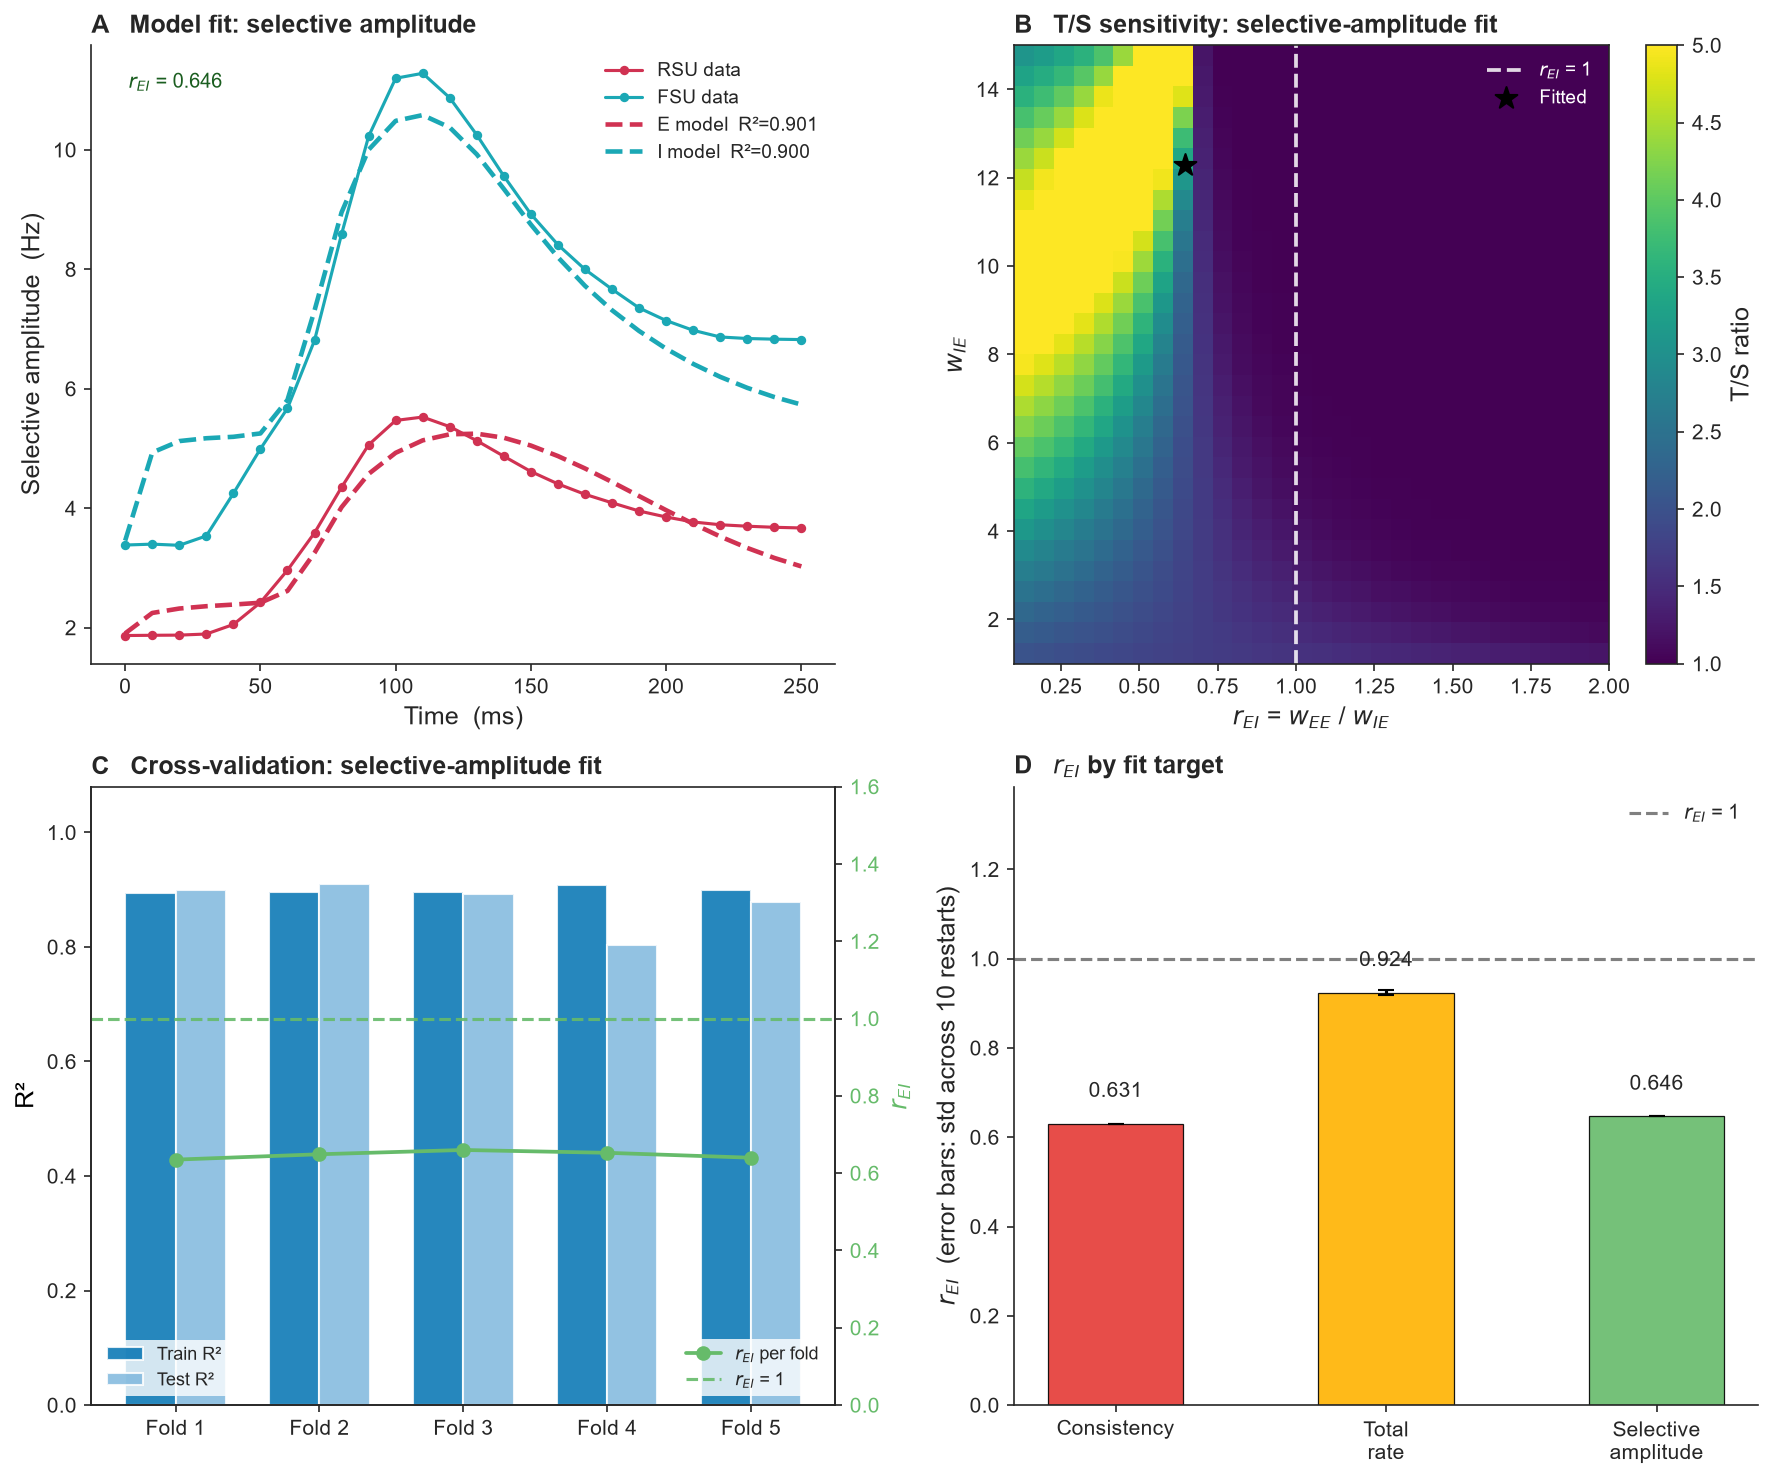

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# ── Panel A: model fit to selective amplitude ────────────────────────────────
ax = axes[0, 0]
ax.plot(fit_sel['t'], fit_sel['data_r'], 'o-', color=COL_RSU, markersize=3.5,
        linewidth=1.5, label='RSU data')
ax.plot(fit_sel['t'], fit_sel['data_f'], 'o-', color=COL_FSU, markersize=3.5,
        linewidth=1.5, label='FSU data')
ax.plot(fit_sel['t'], fit_sel['E_sc'], '--', color=COL_RSU, linewidth=2.2,
        label=f'E model  R²={fit_sel["r2_E"]:.3f}')
ax.plot(fit_sel['t'], fit_sel['I_sc'], '--', color=COL_FSU, linewidth=2.2,
        label=f'I model  R²={fit_sel["r2_I"]:.3f}')
ax.annotate(f'$r_{{EI}}$ = {fit_sel["r_EI"]:.3f}',
            xy=(0.05, 0.93), xycoords='axes fraction', fontsize=9.5, color=COL_FIT,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
ax.set_xlabel('Time  (ms)')
ax.set_ylabel('Selective amplitude  (Hz)')
ax.set_title('A   Model fit: selective amplitude', loc='left', fontweight='bold', pad=6)
ax.legend(frameon=False, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

# ── Panel B: T/S sensitivity heatmap (selective-amplitude fit) ───────────────
ax = axes[0, 1]
im = ax.imshow(ts_grid_sel, origin='lower', aspect='auto',
               extent=[r_EI_range[0], r_EI_range[-1],
                       w_IE_range[0], w_IE_range[-1]],
               cmap='viridis', vmin=1, vmax=5)
ax.axvline(1.0, color='white', linestyle='--', linewidth=1.8, alpha=0.85,
           label='$r_{EI}$ = 1')
ax.scatter([fit_sel['params'][0]], [fit_sel['params'][1]], color='black', s=120,
           zorder=5, marker='*', label='Fitted')
plt.colorbar(im, ax=ax, label='T/S ratio')
ax.set_xlabel('$r_{EI}$ = $w_{EE}$ / $w_{IE}$')
ax.set_ylabel('$w_{IE}$')
ax.set_title('B   T/S sensitivity: selective-amplitude fit', loc='left',
             fontweight='bold', pad=6)
ax.legend(frameon=False, fontsize=9, labelcolor='white')

# ── Panel C: cross-validation (selective-amplitude fit) ──────────────────────
ax  = axes[1, 0]
ax2 = ax.twinx()
x   = np.arange(1, N_FOLDS + 1)
w   = 0.35
ax.bar(x - w/2, df_cv_sel['r2_train'], w, color=COL_DATA, alpha=0.85, label='Train R²')
ax.bar(x + w/2, df_cv_sel['r2_test'],  w, color=COL_TEST, alpha=0.85, label='Test R²')
ax.set_ylabel('R²', color='black')
ax.set_ylim(0, 1.08)
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i}' for i in x])
leg1 = ax.legend(frameon=True, fontsize=8.5, loc='lower left')
leg1.get_frame().set_facecolor('white')
leg1.get_frame().set_alpha(0.8)
leg1.get_frame().set_edgecolor('none')

ax2.plot(x, df_cv_sel['r_EI'], 'o-', color=COL_TARGET_SELECTIVE, linewidth=1.8, markersize=6,
         label='$r_{EI}$ per fold')
ax2.axhline(1.0, color=COL_TARGET_SELECTIVE, linestyle='--', linewidth=1.5, alpha=0.9,
            label='$r_{EI}$ = 1')
ax2.set_ylabel('$r_{EI}$', color=COL_TARGET_SELECTIVE)
ax2.tick_params(axis='y', labelcolor=COL_TARGET_SELECTIVE)
ax2.set_ylim(0, 1.6)
leg2 = ax2.legend(frameon=True, fontsize=8.5, loc='lower right')
leg2.get_frame().set_facecolor('white')
leg2.get_frame().set_alpha(0.8)
leg2.get_frame().set_edgecolor('none')
ax.set_title('C   Cross-validation: selective-amplitude fit', loc='left',
             fontweight='bold', pad=6)
ax.spines['top'].set_visible(False)

# ── Panel D: r_EI across fit targets ─────────────────────────────────────────
ax = axes[1, 1]
labels_cmp = ['Consistency', 'Total\nrate', 'Selective\namplitude']
vals_cmp   = [r_EI_fit, fit_rate['r_EI'], fit_sel['r_EI']]
errs_cmp   = [stab_r_EI.std(), fit_rate['stab'].std(), fit_sel['stab'].std()]
cols_cmp   = [COL_TARGET_CONSISTENCY, COL_TARGET_TOTAL_RATE, COL_TARGET_SELECTIVE]
bars = ax.bar(labels_cmp, vals_cmp, yerr=errs_cmp, capsize=4,
              color=cols_cmp, alpha=0.9, width=0.5, edgecolor='black', linewidth=0.6)
for bar, v in zip(bars, vals_cmp):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.05, f'{v:.3f}',
            ha='center', va='bottom', fontsize=10)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1.5, label='$r_{EI}$ = 1')
ax.set_ylabel('$r_{EI}$  (error bars: std across 10 restarts)')
ax.set_ylim(0, max(vals_cmp) * 1.5)
ax.set_title('D   $r_{EI}$ by fit target', loc='left', fontweight='bold', pad=6)
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)

print_figure_data(
    "Fig. 6A - model fit to selective amplitude",
    time_ms=fit_sel['t'], rsu_data_hz=fit_sel['data_r'], fsu_data_hz=fit_sel['data_f'],
    e_model_fit_hz=fit_sel['E_sc'], i_model_fit_hz=fit_sel['I_sc'],
    r_EI_fit=fit_sel['r_EI'], r2_rsu=fit_sel['r2_E'], r2_fsu=fit_sel['r2_I'],
)
print_figure_data(
    "Fig. 6B - T/S sensitivity heatmap, selective-amplitude fit",
    r_EI_range=r_EI_range, w_IE_range=w_IE_range, ts_ratio_grid=ts_grid_sel,
    fitted_r_EI=fit_sel['params'][0], fitted_w_IE=fit_sel['params'][1],
)
print_figure_data(
    "Fig. 6C - cross-validation, selective-amplitude fit",
    fold_number=x, train_r2_per_fold=df_cv_sel['r2_train'].to_numpy(),
    test_r2_per_fold=df_cv_sel['r2_test'].to_numpy(),
    r_EI_per_fold=df_cv_sel['r_EI'].to_numpy(),
    mean_r_EI=df_cv_sel['r_EI'].mean(), std_r_EI=df_cv_sel['r_EI'].std(),
)
print_figure_data(
    "Fig. 6D - r_EI by fit target",
    labels=labels_cmp, r_EI_values=np.array(vals_cmp), r_EI_stds=np.array(errs_cmp),
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig6_ei_model.png', bbox_inches='tight')
plt.show()


Fig. S9A - model fit: consistency

--- time_ms ---
shape=(26,)
[  0.  10.  20.  30.  40.  50.  60.  70.  80.  90. 100. 110. 120. 130. 140. 150. 160. 170. 180. 190.]
...[26 elements total]

--- rsu_data ---
shape=(26,)
[ 0.000113  0.000469 -0.000391  0.00026   0.017664  0.052822  0.092597  0.132544  0.176763  0.20356   0.216614  0.214299  0.206063  0.196086  0.182063  0.169814  0.160554  0.155011  0.149581
  0.143359]
...[26 elements total]

--- fsu_data ---
shape=(26,)
[ 0.00105  -0.000003 -0.002282  0.00071   0.018162  0.046954  0.076973  0.127985  0.1889    0.224198  0.245251  0.243226  0.218311  0.196396  0.185276  0.170788  0.155804  0.14481   0.137803
  0.131533]
...[26 elements total]

--- e_model_fit ---
shape=(26,)
[0.001779 0.024501 0.031521 0.035939 0.03926  0.042776 0.060677 0.105577 0.146691 0.173649 0.190246 0.200172 0.205557 0.207244 0.205522 0.200726 0.193348 0.183991 0.173295 0.161861]
...[26 elements total]

--- i_model_fit ---
shape=(26,)
[0.000194 0.046317 0.053008 

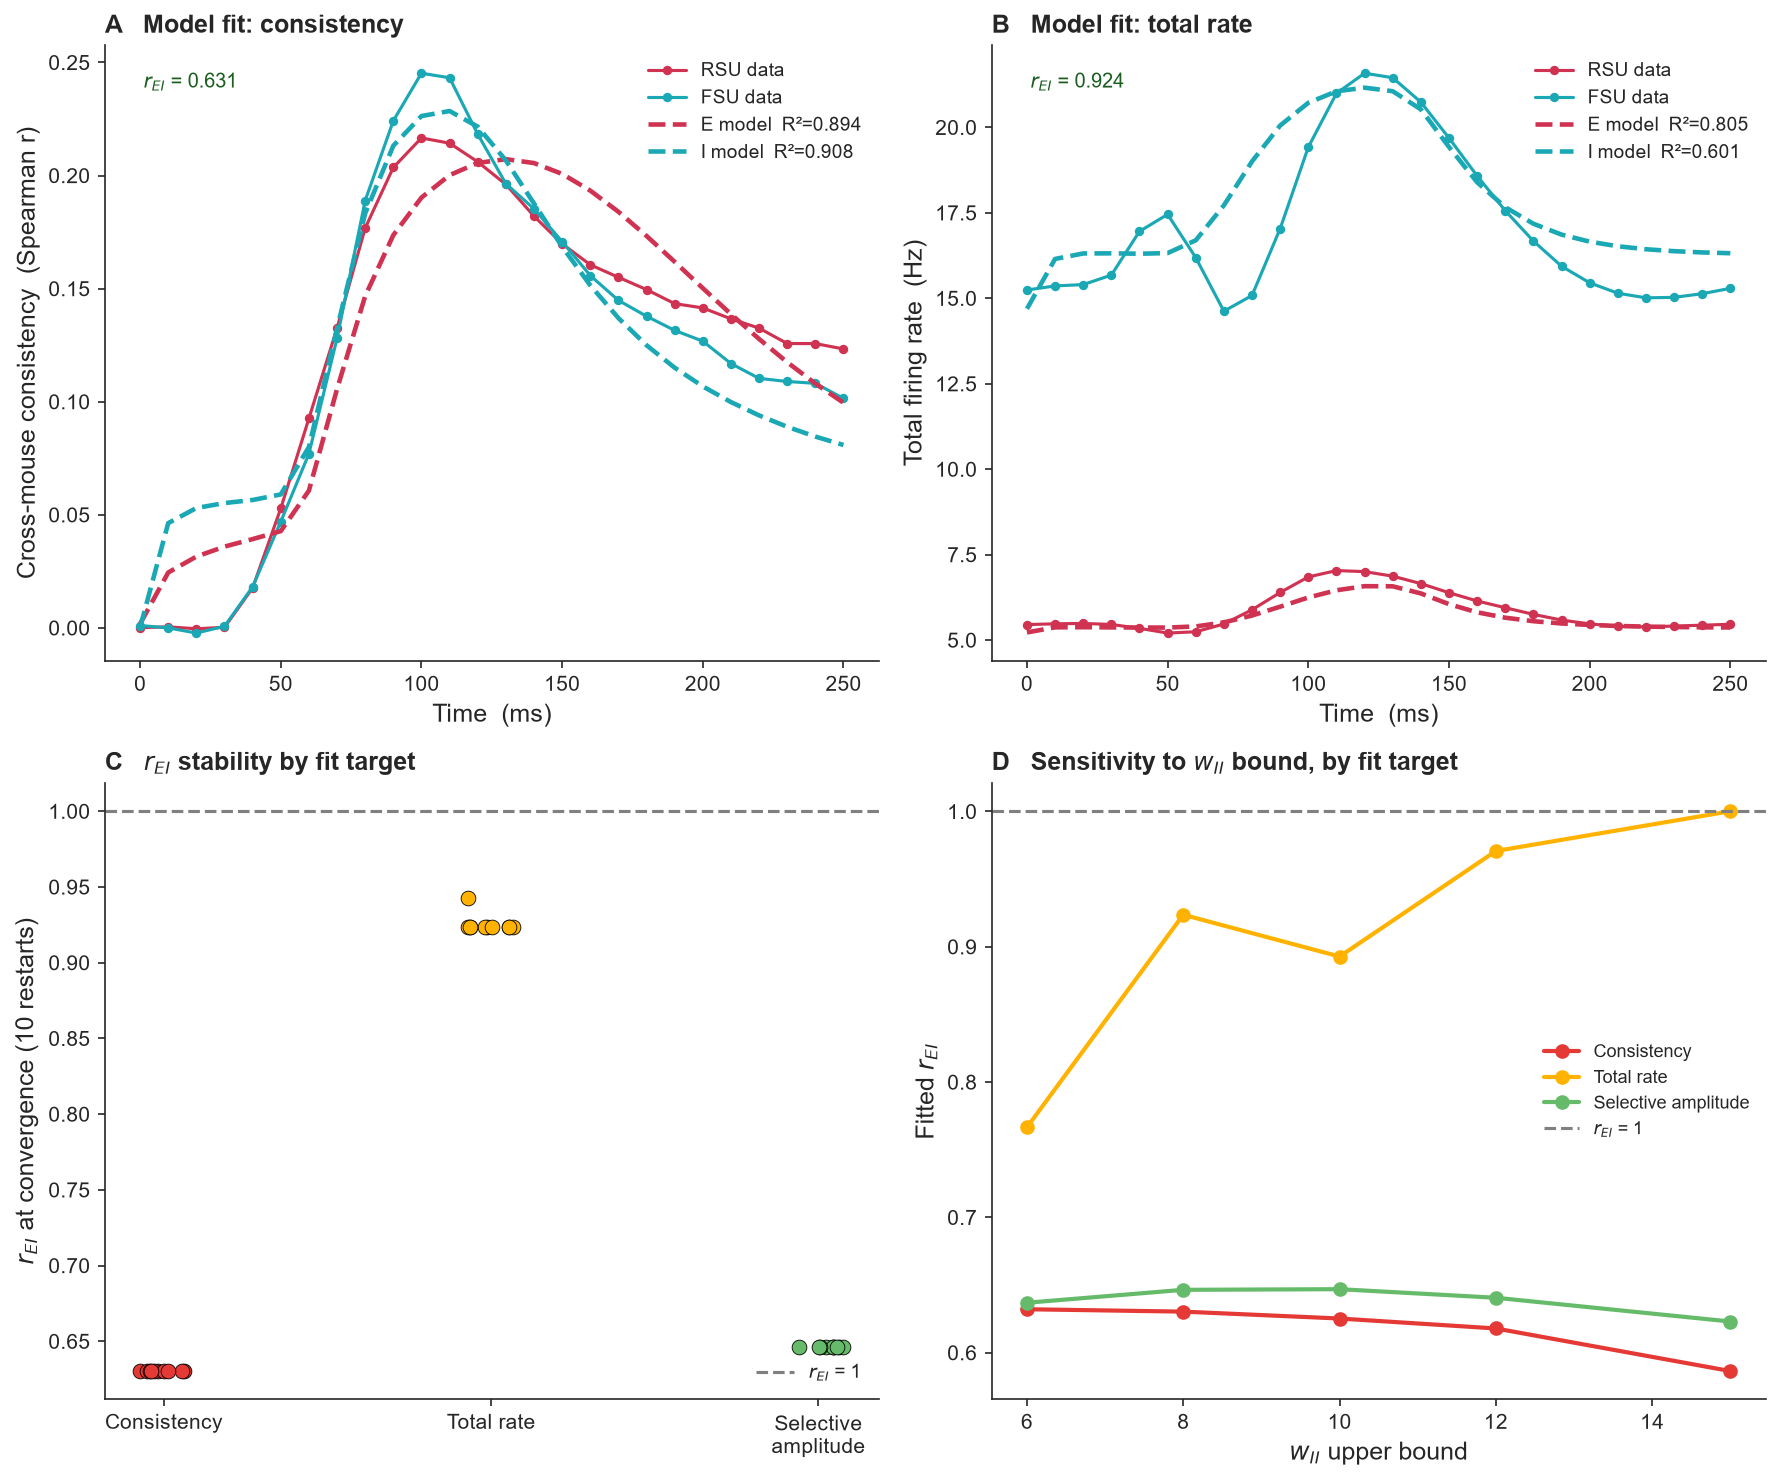

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# ── Panel A: consistency data vs. model fit ──────────────────────────────────
ax = axes[0, 0]
ax.plot(t_r, c_r, 'o-', color=COL_RSU, markersize=3.5, linewidth=1.5, label='RSU data')
ax.plot(t_f, c_f, 'o-', color=COL_FSU, markersize=3.5, linewidth=1.5, label='FSU data')
ax.plot(t_r, E_sc, '--', color=COL_RSU, linewidth=2.2, label=f'E model  R²={r2_E:.3f}')
ax.plot(t_r, I_sc, '--', color=COL_FSU, linewidth=2.2, label=f'I model  R²={r2_I:.3f}')
ax.annotate(f'$r_{{EI}}$ = {r_EI_fit:.3f}', xy=(0.05, 0.93), xycoords='axes fraction',
            fontsize=9.5, color=COL_FIT,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
ax.set_xlabel('Time  (ms)')
ax.set_ylabel('Cross-mouse consistency  (Spearman r)')
ax.set_title('A   Model fit: consistency', loc='left', fontweight='bold', pad=6)
ax.legend(frameon=False, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

# ── Panel B: total-rate data vs. model fit ───────────────────────────────────
ax = axes[0, 1]
ax.plot(fit_rate['t'], fit_rate['data_r'], 'o-', color=COL_RSU, markersize=3.5,
        linewidth=1.5, label='RSU data')
ax.plot(fit_rate['t'], fit_rate['data_f'], 'o-', color=COL_FSU, markersize=3.5,
        linewidth=1.5, label='FSU data')
ax.plot(fit_rate['t'], fit_rate['E_sc'], '--', color=COL_RSU, linewidth=2.2,
        label=f'E model  R²={fit_rate["r2_E"]:.3f}')
ax.plot(fit_rate['t'], fit_rate['I_sc'], '--', color=COL_FSU, linewidth=2.2,
        label=f'I model  R²={fit_rate["r2_I"]:.3f}')
ax.annotate(f'$r_{{EI}}$ = {fit_rate["r_EI"]:.3f}', xy=(0.05, 0.93), xycoords='axes fraction',
            fontsize=9.5, color=COL_FIT,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
ax.set_xlabel('Time  (ms)')
ax.set_ylabel('Total firing rate  (Hz)')
ax.set_title('B   Model fit: total rate', loc='left', fontweight='bold', pad=6)
ax.legend(frameon=False, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

# ── Panel C: r_EI stability across fit targets ───────────────────────────────
ax = axes[1, 0]
stab_sets = [stab_r_EI, fit_rate['stab'], fit_sel['stab']]
labels_st = ['Consistency', 'Total rate', 'Selective\namplitude']
cols_st   = [COL_TARGET_CONSISTENCY, COL_TARGET_TOTAL_RATE, COL_TARGET_SELECTIVE]
for i, (stab, col) in enumerate(zip(stab_sets, cols_st)):
    ax.scatter(np.full(len(stab), i) + rng.uniform(-0.08, 0.08, len(stab)),
               stab, color=col, s=50, zorder=3, edgecolor='black', linewidth=0.4)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1.5, label='$r_{EI}$ = 1')
ax.set_xticks(range(3))
ax.set_xticklabels(labels_st)
ax.set_ylabel('$r_{EI}$ at convergence (10 restarts)')
ax.set_title('C   $r_{EI}$ stability by fit target', loc='left', fontweight='bold', pad=6)
ax.legend(frameon=False, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

# ── Panel D: w_II upper bound sensitivity, all three fit targets ────────────
# Reuses the informed start (not each fit's own optimum) for every target,
# matching how the original consistency-only version of this check was run.
def w_ii_sensitivity(target_rsu, target_fsu, w_II_bounds_test):
    t_a, a_r, a_r_n, t_b, a_f, a_f_n = prep_curves(ts_rsu, target_rsu, ts_fsu, target_fsu)

    def loss_fn(params):
        try:
            E, I = simulate(params, t_a)
            E_n  = (E - E.min()) / (E.max() - E.min() + 1e-8)
            I_n  = (I - I.min()) / (I.max() - I.min() + 1e-8)
            return np.mean((E_n - a_r_n)**2) + np.mean((I_n - a_f_n)**2)
        except Exception:
            return 1e6

    r_EI_vals = []
    for ub in w_II_bounds_test:
        bounds_test = BOUNDS[:3] + [(0.0, ub)] + BOUNDS[4:]
        try:
            res = minimize(loss_fn, x0_informed, method='L-BFGS-B', bounds=bounds_test,
                           options={'maxiter': 2000, 'ftol': 1e-12})
            r_EI_vals.append(res.x[0])
        except Exception:
            r_EI_vals.append(np.nan)
    return r_EI_vals

w_II_bounds_test = [6.0, 8.0, 10.0, 12.0, 15.0]
r_EI_at_bounds_consistency = w_ii_sensitivity(mc_rsu, mc_fsu, w_II_bounds_test)
r_EI_at_bounds_rate        = w_ii_sensitivity(rate_rsu, rate_fsu, w_II_bounds_test)
r_EI_at_bounds_selective   = w_ii_sensitivity(sel_rsu, sel_fsu, w_II_bounds_test)

ax = axes[1, 1]
ax.plot(w_II_bounds_test, r_EI_at_bounds_consistency, 'o-', color=COL_TARGET_CONSISTENCY,
        linewidth=2, markersize=6, label='Consistency')
ax.plot(w_II_bounds_test, r_EI_at_bounds_rate, 'o-', color=COL_TARGET_TOTAL_RATE,
        linewidth=2, markersize=6, label='Total rate')
ax.plot(w_II_bounds_test, r_EI_at_bounds_selective, 'o-', color=COL_TARGET_SELECTIVE,
        linewidth=2, markersize=6, label='Selective amplitude')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1.5, label='$r_{EI}$ = 1')
ax.set_xlabel('$w_{II}$ upper bound')
ax.set_ylabel('Fitted $r_{EI}$')
ax.set_title('D   Sensitivity to $w_{II}$ bound, by fit target', loc='left',
             fontweight='bold', pad=6)
ax.legend(frameon=False, fontsize=8.5)
ax.spines[['top', 'right']].set_visible(False)

print_figure_data(
    "Fig. S9A - model fit: consistency",
    time_ms=t_r, rsu_data=c_r, fsu_data=c_f, e_model_fit=E_sc, i_model_fit=I_sc,
    r_EI_fit=r_EI_fit, r2_rsu=r2_E, r2_fsu=r2_I,
)
print_figure_data(
    "Fig. S9B - model fit: total rate",
    time_ms=fit_rate['t'], rsu_data_hz=fit_rate['data_r'], fsu_data_hz=fit_rate['data_f'],
    e_model_fit_hz=fit_rate['E_sc'], i_model_fit_hz=fit_rate['I_sc'],
    r_EI_fit=fit_rate['r_EI'], r2_rsu=fit_rate['r2_E'], r2_fsu=fit_rate['r2_I'],
)
print_figure_data(
    "Fig. S9C - r_EI stability by fit target",
    labels=labels_st,
    r_EI_consistency=stab_r_EI, r_EI_total_rate=fit_rate['stab'],
    r_EI_selective_amplitude=fit_sel['stab'],
)
print_figure_data(
    "Fig. S9D - sensitivity of fitted r_EI to w_II upper bound, by fit target",
    w_II_upper_bound_tested=np.array(w_II_bounds_test),
    r_EI_at_bound_consistency=np.array(r_EI_at_bounds_consistency),
    r_EI_at_bound_total_rate=np.array(r_EI_at_bounds_rate),
    r_EI_at_bound_selective_amplitude=np.array(r_EI_at_bounds_selective),
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'figS9.png', bbox_inches='tight')
plt.show()